### OpenSea NFT 경매(Auction) 거래 분류
##### 다중 분류(Multiclass Classification)
- 2019년 ~ 2021년 OpenSea에서 발생한 NFT 거래 데이터를 수집했다.
- 각 거래는 Collectibles, Art, Virtual Worlds 등 여러 Category 중 하나에 속한다.
- 거래 메타정보(거래 시각, 가격, 결제 토큰, 판매 횟수 등)를 바탕으로 NFT의 Category를 예측하는 모델을 구축한다.

##### feature
- year / month / hour / day_of_week / is_weekend: 거래 시각 기반 파생
- total_price_eth: 거래 금액 (log1p 변환으로 heavy-tail 완화)
- payment_token_usd_price: 결제 토큰 USD 환율 (log1p)
- num_sales: 자산 누적 판매 횟수 (log1p)
- collection_freq: 해당 NFT 컬렉션의 거래 빈도 (Frequency Encoding — 카테고리의 강한 predictor)
- payment_token: 결제 토큰 종류 (Ether / Wrapped Ether / Other)

##### target
- Category: NFT 카테고리 (Collectibles, Art, Virtual Worlds, Utility, Trading Cards)
- Uncategorized 제거 + 각 클래스를 최소 클래스 수에 맞춰 언더샘플링하여 균형 맞춤

In [1]:
import pandas as pd

nft_df = pd.read_csv('./datasets/OpenSea_NFT_Sales_2019_2021.csv', low_memory=False)
nft_df = nft_df.sample(n=100000, random_state=124).reset_index(drop=True)
nft_df

,sales_datetime,id,asset.id,asset.name,asset.collection.name,asset.collection.short_description,asset.permalink,total_price,payment_token.name,payment_token.usd_price,asset.num_sales,seller.address,seller.user.username,winner_account.address,Category
0,2021-08-28 08:25:45,668754486,41120300,Chad #8727,Chads NFT,NaN,https://opensea.io/assets/0x9cf63efbe189091b7e...,40000000000000000,Ether,3644.46,1,0x376078ab164faba5891f77e70bab2eb4e1b89c3a,Stryker884,0xe3f4b8781381c36d5c6951ceee2fe35dd9cf3e63,Collectibles
1,2021-08-22 16:40:20,602091373,34354715,PixelCat 5386,24px,NaN,https://opensea.io/assets/0x495f947276749ce646...,240000000000000000,Ether,3689.36,3,0xde4db74a280f55f649bb20c845af12f95223eae7,jayto,0x3ff23183a9c70665c14831e10cc6297b6ffd157c,Collectibles
2,2020-12-04 19:58:15,75605864,17165153,"BFH Sphere: #40560004, Lv: 53",Brave Frontier Heroes,NaN,https://opensea.io/assets/0xc03844f07f86ad1d90...,25000000000000000,Ether,3815.21,1,0xa63c72f57eaec7bef6cf6ce5c61cfde05dae9fcf,PoP,0x3c325dae6ca198631b4a9f4b9f5d7e1bd6d8ab6b,Virtual Worlds
3,2021-02-27 18:54:18,80692740,18269838,Spaced Out,Meme Ltd.,NaN,https://opensea.io/assets/0xe4605d46fd0b3f8329...,3940000000000000000,Ether,3815.21,18,0x905213a93f0d202462c3379301e62a74c4aa56ec,bhaiko,0xab6ca2017548a170699890214bfd66583a0c1754,Collectibles
4,2021-10-18 05:28:28,1421732447,57615801,Wassie 11915,loomlocknft (Wassies),NaN,https://opensea.io/assets/0x1d20a51f088492a0f1...,1100000000000000000,Ether,3827.27,1,0x92877703f0f38e0740e43ed7fe414a2dbbbec3fb,NaN,0x58e2f48948a90cd89245117e5366268b3560d990,Collectibles
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2021-08-18 04:41:28,562550091,37376378,Wicked Ape #9046,Wicked Ape Bone Club,NaN,https://opensea.io/assets/0xbe6e3669464e7db1e1...,250000000000000000,Ether,3732.09,1,0x2491403bd141d8aa64425b612987dc0a4cf8d265,NaN,0xda6776bfba3252e6720911c4ed6a317e98d4954f,Collectibles
99996,2021-12-02 10:39:17,2281055214,125032673,Crypto bull #165,Crypto Bull Society,NaN,https://opensea.io/assets/0x469823c7b84264d1ba...,1888000000000000000,Ether,3833.11,1,0x62941f356d3970e8d664dec2c582ee2ec3805548,DaOhGee,0x957b9ddcb99fe4bce41da4e6d8e61ef2cc3af055,Collectibles
99997,2021-10-04 02:43:45,1229942571,51591207,Pythagorean Mask # 2664,Pythagorean Masks,NaN,https://opensea.io/assets/0x6327f6305331f7e0cc...,27000000000000000,Ether,3824.22,1,0xf266ec07bced0c64514dc0f7ab1bbc56dc2aff9c,Oliverrr,0x4450bd53845e47a337bdd4248144ccad289fd56b,Collectibles
99998,2021-08-23 23:13:21,617239121,34149131,Flowers #5672,Flowers by RVig,NaN,https://opensea.io/assets/0xa7d8d9ef8d8ce8992d...,250000000000000000,Ether,3689.36,2,0xc39c550825fdf5d44eab12d0bb319ae3144ba557,jsunNFT,0x0e5a1d84ed69067c078596bc6a17452425b005f1,Art


In [2]:
nft_df.isna().sum()

sales_datetime                            0
id                                        0
asset.id                                  0
asset.name                             5799
asset.collection.name                   935
asset.collection.short_description    99020
asset.permalink                         935
total_price                               0
payment_token.name                       29
payment_token.usd_price                  60
asset.num_sales                           0
seller.address                            0
seller.user.username                  11162
winner_account.address                    0
Category                                  0
dtype: int64

In [3]:
nft_df.duplicated().sum()

np.int64(0)

In [4]:
import numpy as np
from sklearn.utils import resample

nft_df['sales_datetime'] = pd.to_datetime(nft_df['sales_datetime'], errors='coerce')
nft_df['year'] = nft_df['sales_datetime'].dt.year
nft_df['month'] = nft_df['sales_datetime'].dt.month
nft_df['hour'] = nft_df['sales_datetime'].dt.hour
nft_df['day_of_week'] = nft_df['sales_datetime'].dt.dayofweek
nft_df['is_weekend'] = (nft_df['day_of_week'] >= 5).astype(int)

# 수치 피처: log1p 변환으로 heavy-tail 완화
nft_df['total_price_eth'] = np.log1p(nft_df['total_price'].astype(float) / 1e18)
nft_df['payment_token_usd_price'] = np.log1p(
    nft_df['payment_token.usd_price'].astype(float).clip(lower=0))
nft_df['num_sales'] = np.log1p(nft_df['asset.num_sales'].astype(float))

# payment_token 그룹화
def group_token(name):
    if name == 'Ether':
        return 'Ether'
    if name == 'Wrapped Ether':
        return 'Wrapped Ether'
    return 'Other'

nft_df['payment_token'] = nft_df['payment_token.name'].apply(group_token)

# 컬렉션 이름은 원본만 유지 (Frequency Encoding은 split 이후 train 기준으로 계산 -> leakage 방지)
nft_df['collection_name'] = nft_df['asset.collection.name'].fillna('unknown')

cols = ['year', 'month', 'hour', 'day_of_week', 'is_weekend',
        'total_price_eth', 'payment_token_usd_price', 'num_sales',
        'collection_name', 'payment_token', 'Category']
nft_df = nft_df[cols].dropna().reset_index(drop=True)

# Uncategorized 제거 + 상위 5개 카테고리만 유지
keep_categories = ['Collectibles', 'Art', 'Virtual Worlds', 'Utility', 'Trading Cards']
nft_df = nft_df[nft_df.Category.isin(keep_categories)].reset_index(drop=True)

# 클래스 언더샘플링: 가장 작은 클래스 수에 맞춰 균형화
min_count = nft_df.Category.value_counts().min()
balanced_parts = [
    resample(nft_df[nft_df.Category == c],
             n_samples=min_count, replace=False, random_state=124)
    for c in keep_categories
]
nft_df = pd.concat(balanced_parts).sample(frac=1, random_state=124).reset_index(drop=True)

print('클래스별 행 수:')
print(nft_df.Category.value_counts())
nft_df


클래스별 행 수:
Category
Trading Cards     1604
Collectibles      1604
Utility           1604
Art               1604
Virtual Worlds    1604
Name: count, dtype: int64


,year,month,hour,day_of_week,is_weekend,total_price_eth,payment_token_usd_price,num_sales,collection_name,payment_token,Category
0,2021,8,19,1,0,0.048790,8.224992,0.693147,Rosko Sees the Future: A Tarot Card Project,Ether,Trading Cards
1,2021,12,22,2,0,0.008960,8.235345,0.693147,Skeletongues,Ether,Collectibles
2,2021,8,20,3,0,0.139762,8.224992,1.098612,Playing Arts Crypto Edition,Ether,Trading Cards
3,2021,9,9,1,0,0.057325,8.227512,1.098612,Role for Metaverse,Ether,Trading Cards
4,2021,10,13,0,0,0.058269,8.241282,1.609438,CryptoMories,Ether,Collectibles
...,...,...,...,...,...,...,...,...,...,...,...
8015,2021,10,4,1,0,0.090754,8.243335,0.693147,Toucan Gang,Ether,Collectibles
8016,2021,10,4,1,0,0.122218,8.248474,1.098612,TinyPaws,Ether,Collectibles
8017,2021,8,4,3,0,0.122218,8.216048,0.693147,Crypto Gem Alliance,Ether,Utility
8018,2021,9,11,4,0,0.559616,8.225251,1.098612,Realms (for Adventurers),Ether,Virtual Worlds


In [5]:
nft_df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,8020.0,2020.870075,0.441999,2019.000000,2021.000000,2021.000000,2021.000000,2021.000000
month,8020.0,9.038155,2.393363,1.000000,8.000000,9.000000,11.000000,12.000000
hour,8020.0,11.787656,7.268593,0.000000,5.000000,12.000000,18.000000,23.000000
day_of_week,8020.0,2.892269,1.986264,0.000000,1.000000,3.000000,5.000000,6.000000
is_weekend,8020.0,0.258354,0.437757,0.000000,0.000000,0.000000,1.000000,1.000000
total_price_eth,8020.0,0.370234,0.755247,0.000000,0.058269,0.139762,0.343537,9.680406
payment_token_usd_price,8020.0,8.125282,0.895804,0.010096,8.225787,8.232743,8.246376,8.325204
num_sales,8020.0,1.582084,1.764104,0.000000,0.693147,1.098612,1.386294,9.807472


<Axes: >

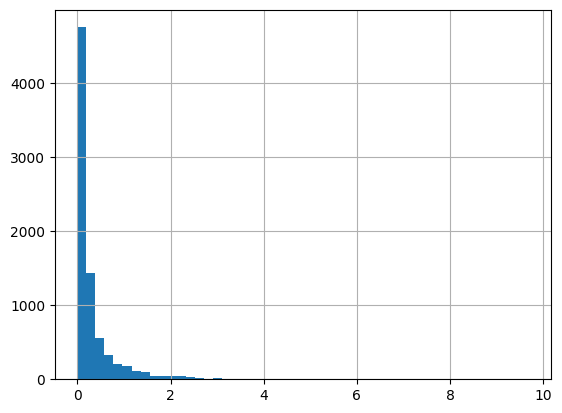

In [6]:
nft_df.total_price_eth.hist(bins=50)

In [7]:
Q1 = nft_df.total_price_eth.describe().T['25%']
Q3 = nft_df.total_price_eth.describe().T['75%']

iqr = Q3 - Q1

lower_bound = Q1 - 1.5 * iqr
upper_bound = Q3 + 1.5 * iqr
if lower_bound < 0:
    lower_bound = 0
print(f'{lower_bound}~{upper_bound}')

0~0.7714379153500437


In [8]:
nft_df = nft_df[nft_df.total_price_eth < upper_bound].reset_index(drop=True)
nft_df

,year,month,hour,day_of_week,is_weekend,total_price_eth,payment_token_usd_price,num_sales,collection_name,payment_token,Category
0,2021,8,19,1,0,0.048790,8.224992,0.693147,Rosko Sees the Future: A Tarot Card Project,Ether,Trading Cards
1,2021,12,22,2,0,0.008960,8.235345,0.693147,Skeletongues,Ether,Collectibles
2,2021,8,20,3,0,0.139762,8.224992,1.098612,Playing Arts Crypto Edition,Ether,Trading Cards
3,2021,9,9,1,0,0.057325,8.227512,1.098612,Role for Metaverse,Ether,Trading Cards
4,2021,10,13,0,0,0.058269,8.241282,1.609438,CryptoMories,Ether,Collectibles
...,...,...,...,...,...,...,...,...,...,...,...
7068,2021,10,4,1,0,0.090754,8.243335,0.693147,Toucan Gang,Ether,Collectibles
7069,2021,10,4,1,0,0.122218,8.248474,1.098612,TinyPaws,Ether,Collectibles
7070,2021,8,4,3,0,0.122218,8.216048,0.693147,Crypto Gem Alliance,Ether,Utility
7071,2021,9,11,4,0,0.559616,8.225251,1.098612,Realms (for Adventurers),Ether,Virtual Worlds


In [9]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

token_encoder = OneHotEncoder(sparse_output=False)
token_onehot = token_encoder.fit_transform(nft_df[['payment_token']])
token_cols = token_encoder.get_feature_names_out(['payment_token'])
token_onehot_df = pd.DataFrame(data=token_onehot, columns=token_cols, index=nft_df.index)

# collection_name은 일단 유지 (split 이후 frequency encoding 후 제거)
nft_enc_df = pd.concat([nft_df.drop(['payment_token', 'Category'], axis=1), token_onehot_df], axis=1)

category_encoder = LabelEncoder()
categories = category_encoder.fit_transform(nft_df.Category.tolist())
nft_enc_df['Category'] = categories

nft_enc_df


,year,month,hour,day_of_week,is_weekend,total_price_eth,payment_token_usd_price,num_sales,collection_name,payment_token_Ether,payment_token_Other,payment_token_Wrapped Ether,Category
0,2021,8,19,1,0,0.048790,8.224992,0.693147,Rosko Sees the Future: A Tarot Card Project,1.0,0.0,0.0,2
1,2021,12,22,2,0,0.008960,8.235345,0.693147,Skeletongues,1.0,0.0,0.0,1
2,2021,8,20,3,0,0.139762,8.224992,1.098612,Playing Arts Crypto Edition,1.0,0.0,0.0,2
3,2021,9,9,1,0,0.057325,8.227512,1.098612,Role for Metaverse,1.0,0.0,0.0,2
4,2021,10,13,0,0,0.058269,8.241282,1.609438,CryptoMories,1.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7068,2021,10,4,1,0,0.090754,8.243335,0.693147,Toucan Gang,1.0,0.0,0.0,1
7069,2021,10,4,1,0,0.122218,8.248474,1.098612,TinyPaws,1.0,0.0,0.0,1
7070,2021,8,4,3,0,0.122218,8.216048,0.693147,Crypto Gem Alliance,1.0,0.0,0.0,3
7071,2021,9,11,4,0,0.559616,8.225251,1.098612,Realms (for Adventurers),1.0,0.0,0.0,4


In [10]:
nft_enc_df.Category.value_counts()

Category
1    1475
3    1448
2    1446
0    1403
4    1301
Name: count, dtype: int64

In [11]:
print(category_encoder.classes_)
print(token_encoder.categories_)

['Art' 'Collectibles' 'Trading Cards' 'Utility' 'Virtual Worlds']
[array(['Ether', 'Other', 'Wrapped Ether'], dtype=object)]


### 다중 분류(Multiclass) 평가 함수
- pima 노트북 패턴을 다중분류용으로 확장
- 정확도 + macro/weighted precision·recall·F1 + 정규화 혼동행렬


In [12]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
)
import matplotlib.pyplot as plt


def get_evaluation(y_test, prediction, classifier=None, X_test=None, target_names=None):
    confusion = confusion_matrix(y_test, prediction)
    accuracy = accuracy_score(y_test, prediction)
    # 다중분류: macro = 클래스 균등가중, weighted = 샘플 수 가중
    precision_macro = precision_score(y_test, prediction, average='macro', zero_division=0)
    recall_macro = recall_score(y_test, prediction, average='macro', zero_division=0)
    f1_macro = f1_score(y_test, prediction, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, prediction, average='weighted', zero_division=0)

    print('오차 행렬')
    print(confusion)
    print(f'정확도: {accuracy:.4f}')
    print(f'정밀도(macro): {precision_macro:.4f}, 재현율(macro): {recall_macro:.4f}')
    print(f'F1(macro): {f1_macro:.4f}, F1(weighted): {f1_weighted:.4f}')
    print('#' * 60)
    print(classification_report(y_test, prediction, target_names=target_names, zero_division=0))

    if classifier is not None and X_test is not None:
        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
        titles_options = [('Confusion matrix', None), ('Normalized', 'true')]
        for (title, normalize), ax in zip(titles_options, axes.flatten()):
            disp = ConfusionMatrixDisplay.from_estimator(
                classifier, X_test, y_test, ax=ax,
                cmap=plt.cm.Blues, normalize=normalize,
                display_labels=target_names,
                xticks_rotation=45,
            )
            disp.ax_.set_title(title)
        plt.tight_layout()
        plt.show()


In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from scipy.stats import randint

X_all = nft_enc_df.drop(['Category'], axis=1)  # collection_name 원본 아직 포함
y_all = nft_enc_df['Category']

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=124)
X_train = X_train.copy()
X_test = X_test.copy()

# ===== 컬렉션 단위 피처 엔지니어링: 전부 train 기준으로만 집계 (leakage 방지) =====
grouped = X_train.groupby('collection_name')

collection_freq_map     = grouped.size()
price_mean_map          = grouped['total_price_eth'].mean()
price_std_map           = grouped['total_price_eth'].std().fillna(0)
num_sales_mean_map      = grouped['num_sales'].mean()

# unseen collection fallback: train 전체 통계
global_price_mean      = X_train['total_price_eth'].mean()
global_num_sales_mean  = X_train['num_sales'].mean()


def apply_collection_features(df):
    # 등장 빈도 (log1p)
    df['collection_freq'] = np.log1p(
        df['collection_name'].map(collection_freq_map).fillna(0).astype(float))
    # 컬렉션 평균 가격 (Art = high-variance, Collectibles = 대량발행으로 균일)
    df['collection_price_mean'] = (
        df['collection_name'].map(price_mean_map).fillna(global_price_mean))
    # 컬렉션 가격 표준편차 (Art vs Collectibles 구분 핵심 신호)
    df['collection_price_std'] = (
        df['collection_name'].map(price_std_map).fillna(0.0))
    # 컬렉션 평균 재판매 횟수 (Collectibles는 재판매 활발, Art는 1회성 많음)
    df['collection_num_sales_mean'] = (
        df['collection_name'].map(num_sales_mean_map).fillna(global_num_sales_mean))
    return df.drop(['collection_name'], axis=1)


X_train = apply_collection_features(X_train)
X_test  = apply_collection_features(X_test)

feature_columns = X_train.columns.tolist()
print('최종 feature:', feature_columns)
print('X_train shape:', X_train.shape, ' X_test shape:', X_test.shape)

dtc = DecisionTreeClassifier(class_weight='balanced', random_state=124)

parameters = {
    'max_depth': randint(3, 15),
    'min_samples_split': randint(2, 30)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=124)

random_cv = RandomizedSearchCV(
    dtc,
    param_distributions=parameters,
    n_iter=8,
    cv=skf,
    refit=True,
    return_train_score=True,
    random_state=124,
    n_jobs=-1,
)

random_cv.fit(X_train, y_train)


최종 feature: ['year', 'month', 'hour', 'day_of_week', 'is_weekend', 'total_price_eth', 'payment_token_usd_price', 'num_sales', 'payment_token_Ether', 'payment_token_Other', 'payment_token_Wrapped Ether', 'collection_freq', 'collection_price_mean', 'collection_price_std', 'collection_num_sales_mean']
X_train shape: (5658, 15)  X_test shape: (1415, 15)


,estimator,DecisionTreeC...dom_state=124)
,param_distributions,"{'max_depth': <scipy.stats....001EB0D6550C0>, 'min_samples_split': <scipy.stats....001EB0F50A470>}"
,n_iter,8
,scoring,None
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,124
,error_score,nan


In [14]:
random_cv_scores = pd.DataFrame(random_cv.cv_results_)
random_cv_scores[['params', 'mean_test_score', 'rank_test_score']].sort_values(by='rank_test_score')

,params,mean_test_score,rank_test_score
6,"{'max_depth': 12, 'min_samples_split': 24}",0.801163,1
5,"{'max_depth': 9, 'min_samples_split': 29}",0.751492,2
4,"{'max_depth': 8, 'min_samples_split': 23}",0.722329,3
3,"{'max_depth': 7, 'min_samples_split': 16}",0.672317,4
1,"{'max_depth': 5, 'min_samples_split': 11}",0.597205,5
0,"{'max_depth': 4, 'min_samples_split': 9}",0.526683,6
2,"{'max_depth': 3, 'min_samples_split': 22}",0.474721,7
7,"{'max_depth': 3, 'min_samples_split': 10}",0.474721,7


In [15]:
from sklearn.model_selection import GridSearchCV

dtc = DecisionTreeClassifier(class_weight='balanced', random_state=124)

parameters = {
    'max_depth': list(range(5, 13)),
    'min_samples_split': list(range(2, 20, 2))
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=124)

grid_cv = GridSearchCV(
    dtc,
    param_grid=parameters,
    cv=skf,
    refit=True,
    return_train_score=True,
    n_jobs=-1,
)

grid_cv.fit(X_train, y_train)


,estimator,DecisionTreeC...dom_state=124)
,param_grid,"{'max_depth': [5, 6, ...], 'min_samples_split': [2, 4, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,criterion,'gini'


In [16]:
grid_cv_scores = pd.DataFrame(grid_cv.cv_results_)
grid_cv_scores[['params', 'mean_test_score', 'rank_test_score']].sort_values(by='rank_test_score').head(20)

,params,mean_test_score,rank_test_score
63,"{'max_depth': 12, 'min_samples_split': 2}",0.839162,1
65,"{'max_depth': 12, 'min_samples_split': 6}",0.835981,2
64,"{'max_depth': 12, 'min_samples_split': 4}",0.835981,3
66,"{'max_depth': 12, 'min_samples_split': 8}",0.831916,4
67,"{'max_depth': 12, 'min_samples_split': 10}",0.827852,5
68,"{'max_depth': 12, 'min_samples_split': 12}",0.826438,6
54,"{'max_depth': 11, 'min_samples_split': 2}",0.826082,7
56,"{'max_depth': 11, 'min_samples_split': 6}",0.822548,8
55,"{'max_depth': 11, 'min_samples_split': 4}",0.822548,9
69,"{'max_depth': 12, 'min_samples_split': 14}",0.820782,10


best params: {'max_depth': 12, 'min_samples_split': 2}

오차 행렬
[[204  72   4   1   0]
 [ 74 212   2   6   1]
 [  9   8 242   2  28]
 [ 15  16   2 255   2]
 [ 24   7   2   0 227]]
정확도: 0.8057
정밀도(macro): 0.8210, 재현율(macro): 0.8069
F1(macro): 0.8118, F1(weighted): 0.8108
############################################################
                precision    recall  f1-score   support

           Art       0.63      0.73      0.67       281
  Collectibles       0.67      0.72      0.70       295
 Trading Cards       0.96      0.84      0.89       289
       Utility       0.97      0.88      0.92       290
Virtual Worlds       0.88      0.87      0.88       260

      accuracy                           0.81      1415
     macro avg       0.82      0.81      0.81      1415
  weighted avg       0.82      0.81      0.81      1415



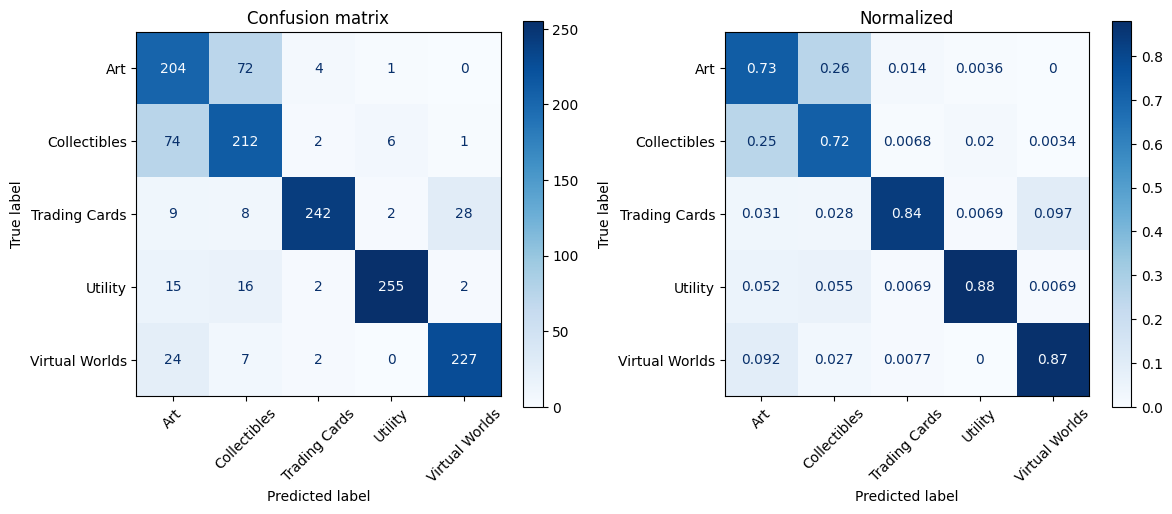

In [17]:
dtc = grid_cv.best_estimator_
pred = dtc.predict(X_test)
print('best params:', grid_cv.best_params_)
print()
get_evaluation(y_test, pred, classifier=dtc, X_test=X_test,
               target_names=category_encoder.classes_)


In [18]:
dtc.feature_importances_

array([0.04894733, 0.03262217, 0.00833372, 0.01076511, 0.00058927,
       0.01020927, 0.02119326, 0.0157402 , 0.00146386, 0.        ,
       0.00125263, 0.3614447 , 0.15757127, 0.17089159, 0.15897561])

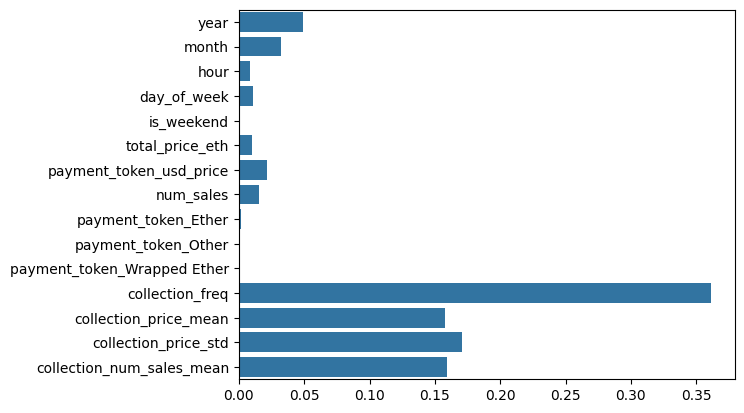

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(x=dtc.feature_importances_, y=feature_columns)
plt.show()


In [20]:
import numpy as np
import matplotlib.pyplot as plt

# 학습된 전체 모델의 결정면을 2D 슬라이스로 시각화
# top 2 피처만 변화시키고 나머지는 중앙값으로 고정해서 모델의 predict를 그대로 사용
def visualize_boundary(model, X_full, top2, y):
    fig, ax = plt.subplots()

    x_col, y_col = top2
    ax.scatter(X_full[x_col], X_full[y_col], c=y, s=20, cmap='rainbow',
               edgecolor='k', clim=(y.min(), y.max()), zorder=3)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    xlim_start, xlim_end = ax.get_xlim()
    ylim_start, ylim_end = ax.get_ylim()

    # 나머지 피처는 중앙값으로 고정 (slice 기준점)
    base_row = X_full.median()

    xx, yy = np.meshgrid(np.linspace(xlim_start, xlim_end, num=200),
                         np.linspace(ylim_start, ylim_end, num=200))

    grid = pd.DataFrame(np.tile(base_row.values, (xx.size, 1)),
                        columns=X_full.columns)
    grid[x_col] = xx.ravel()
    grid[y_col] = yy.ravel()

    # 학습 시점 컬럼 순서대로 정렬 후 예측
    Z = model.predict(grid[X_full.columns].values).reshape(xx.shape)

    n_classes = len(np.unique(y))
    ax.contourf(xx, yy, Z, alpha=0.3,
                levels=np.arange(n_classes + 1) - 0.5,
                cmap='rainbow',
                zorder=1)
    plt.show()

top 2 features: ['collection_freq', 'collection_price_std']


C:\Users\dlwns\anaconda3\envs\machine-learning\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


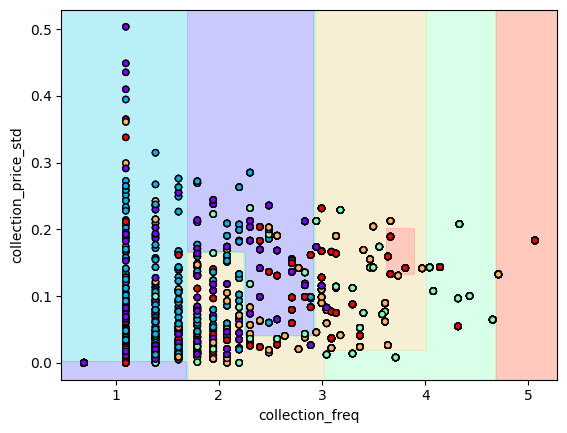

In [21]:
top2 = pd.Series(dtc.feature_importances_, index=feature_columns)\
    .sort_values(ascending=False).head(2).index.tolist()
print('top 2 features:', top2)

visualize_boundary(dtc, X_train, top2, y_train)


### RandomForest 베이스라인 비교
- 단일 DecisionTree는 high variance -> 성능 측정이 seed에 흔들림
- RandomForest는 bagging으로 variance 감소 -> 더 안정적인 "정확한 측정"
- 동일한 X_train / X_test / y_train / y_test 사용 (공정 비교)


=== RandomForest 베이스라인 ===
오차 행렬
[[187  91   1   2   0]
 [ 34 261   0   0   0]
 [  5   8 269   3   4]
 [ 10  17   0 263   0]
 [ 10  15   0   2 233]]
정확도: 0.8572
정밀도(macro): 0.8759, 재현율(macro): 0.8568
F1(macro): 0.8618, F1(weighted): 0.8607
############################################################
                precision    recall  f1-score   support

           Art       0.76      0.67      0.71       281
  Collectibles       0.67      0.88      0.76       295
 Trading Cards       1.00      0.93      0.96       289
       Utility       0.97      0.91      0.94       290
Virtual Worlds       0.98      0.90      0.94       260

      accuracy                           0.86      1415
     macro avg       0.88      0.86      0.86      1415
  weighted avg       0.87      0.86      0.86      1415



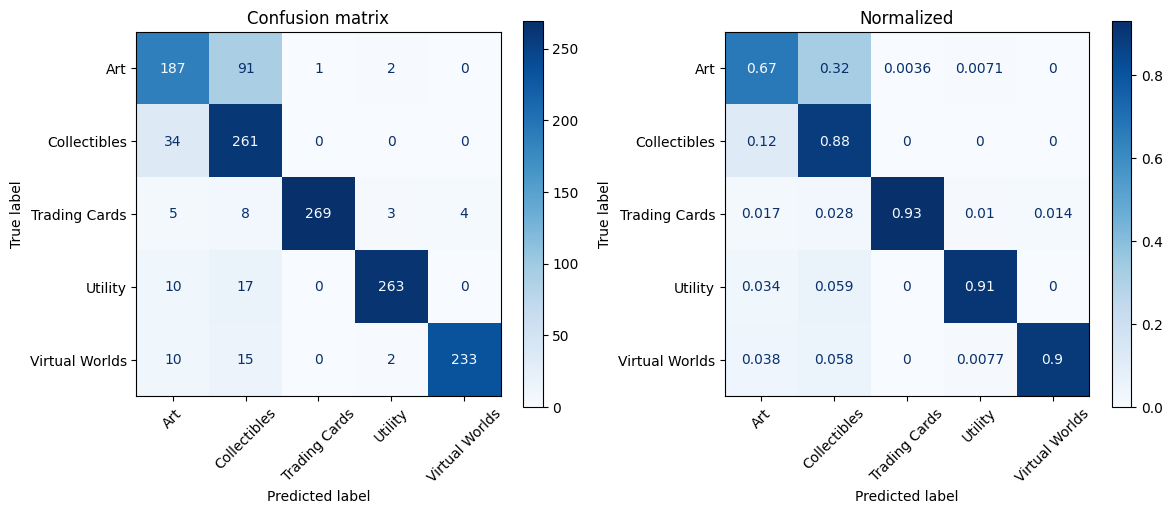

In [22]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    class_weight='balanced',
    random_state=124,
    n_jobs=-1,
)
rfc.fit(X_train, y_train)
pred_rf = rfc.predict(X_test)

print('=== RandomForest 베이스라인 ===')
get_evaluation(y_test, pred_rf, classifier=rfc, X_test=X_test,
               target_names=category_encoder.classes_)


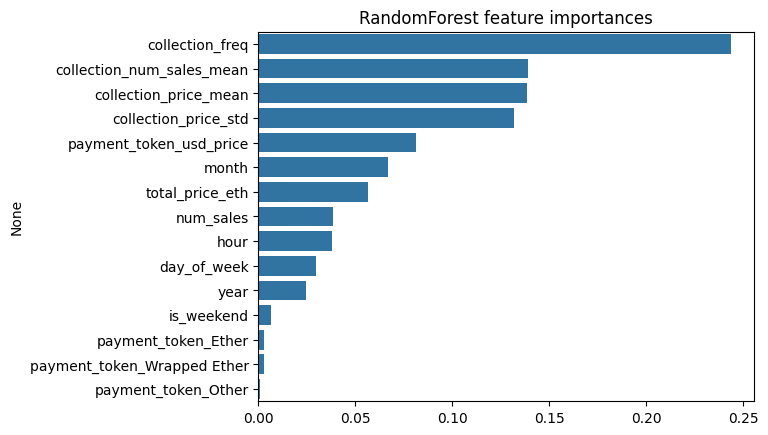

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

rf_imp = pd.Series(rfc.feature_importances_, index=feature_columns)\
    .sort_values(ascending=False)
sns.barplot(x=rf_imp.values, y=rf_imp.index)
plt.title('RandomForest feature importances')
plt.show()
